# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'jhaff2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.20 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

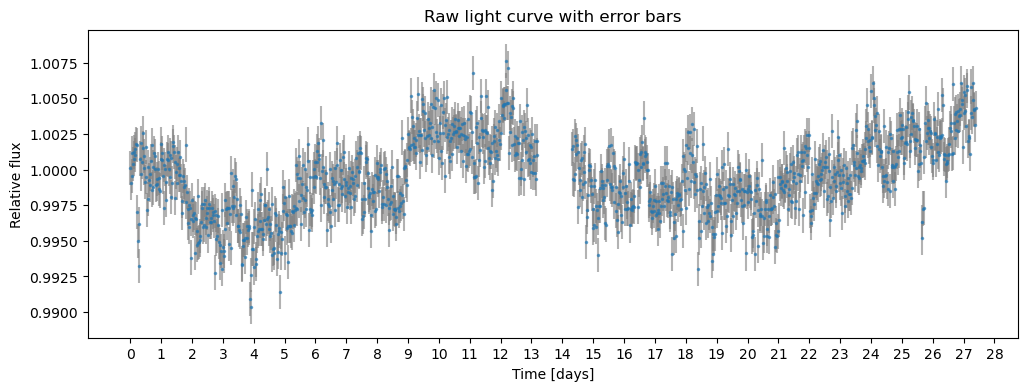

In [2]:
plt.figure(figsize=(12,4))
plt.errorbar(t, flux, yerr=sigma, fmt='.', ms=3, alpha=0.6, ecolor='gray')

# Add more x-axis labels
ticks = np.arange(t.min(), t.max()+1, 1)   # every 2 days
plt.xticks(ticks)

plt.xlabel("Time [days]")
plt.ylabel("Relative flux")
plt.title("Raw light curve with error bars")
plt.show()


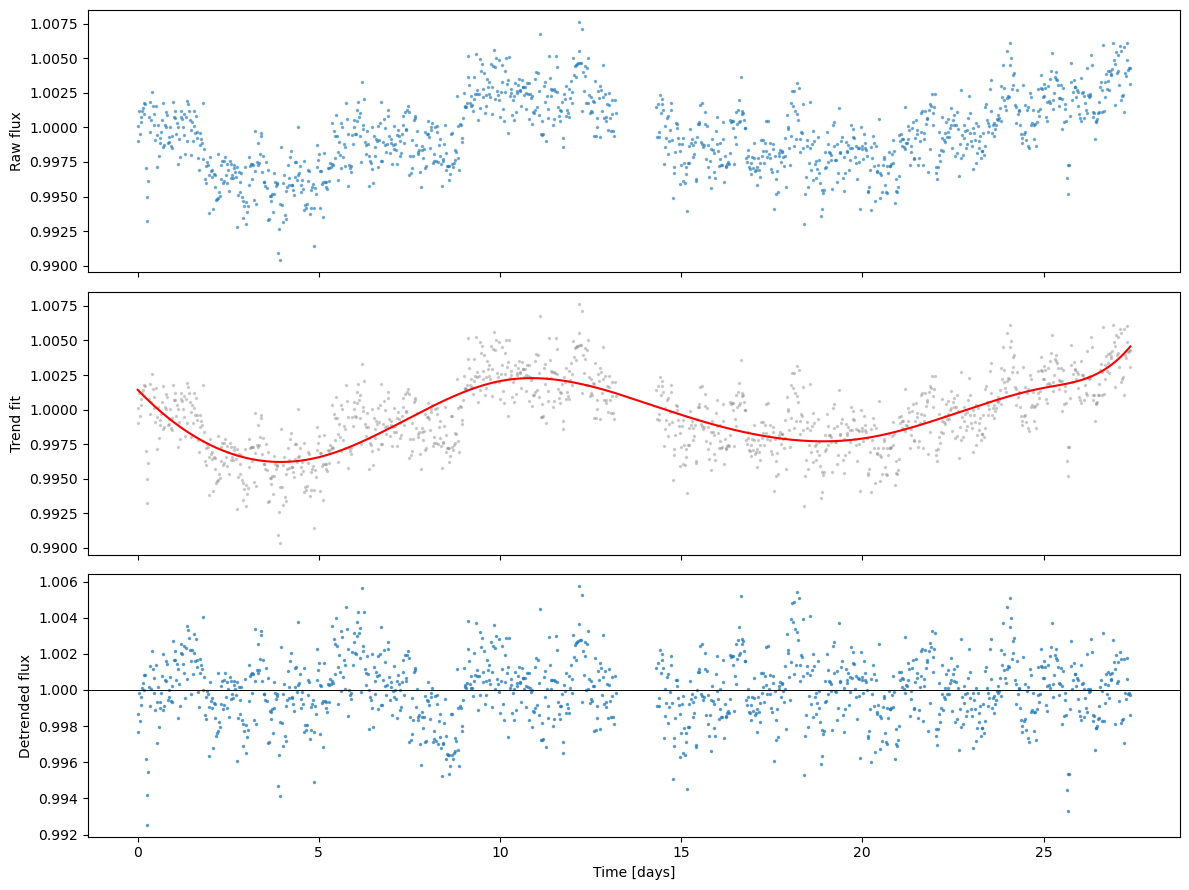

stated sigma_flux      = 1.198 ppt
measured OOT scatter   = 1.779 ppt


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LSQUnivariateSpline
from scipy.signal import medfilt

duration_guess = 0.1  


knot_spacing_days = 5.0   

window_days = 10 * duration_guess
dt = np.median(np.diff(t))
kernel_pts = int(window_days / dt)
kernel_pts += (kernel_pts % 2 == 0)
rough_trend = medfilt(flux, kernel_size=max(kernel_pts, 3))

resid = flux - rough_trend
noise_est = 1.4826 * np.median(np.abs(resid - np.median(resid)))
mask_oot = resid > -4 * noise_est

t_oot, f_oot = t[mask_oot], flux[mask_oot]
order = np.argsort(t_oot)
t_oot, f_oot = t_oot[order], f_oot[order]

# knots only within actual data range, respecting the gap between the two segments
knots = np.arange(t_oot[0] + knot_spacing_days, t_oot[-1], knot_spacing_days)
knots = knots[(knots > t_oot[0] + 0.5) & (knots < t_oot[-1] - 0.5)]  # keep off the edges

spl = LSQUnivariateSpline(t_oot, f_oot, knots, k=3)
trend = spl(t)
detrended = flux / trend

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Raw flux (no error bars)
ax[0].plot(t, flux, '.', ms=3, alpha=0.5)
ax[0].set_ylabel("Raw flux")

ax[1].plot(t, flux, '.', ms=3, alpha=0.3, color='gray')
ax[1].plot(t, trend, 'r-', lw=1.5)
ax[1].set_ylabel("Trend fit")

sigma_detrended = sigma / trend
ax[2].plot(t, detrended, '.', ms=3, alpha=0.6)
ax[2].axhline(1.0, color='k', lw=0.7)
ax[2].set_ylabel("Detrended flux")
ax[2].set_xlabel("Time [days]")

plt.tight_layout()
plt.show()

oot_scatter = np.std(detrended[mask_oot])
print(f"stated sigma_flux      = {np.median(sigma)*1e3:.3f} ppt")
print(f"measured OOT scatter   = {oot_scatter*1e3:.3f} ppt")


**ANSWERS (initial guesses + scatter check):**

t0 = 0.2 days,P = 4 days, : 𝛿 = 1.002 - 0.9930 = 0.009, T= 0.1 day. These are all very rough guesses that I made just by looking at the graphs. The graph that has been detrended also actually looks like the trend has been removed, which is good. 


## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

Best-fit parameters:
  t0       = 0.25407 d
  P        = 4.36231 d
  depth    = 1.992 ppt
  duration = 0.13120 d
  F0       = 1.00004
  converged: True, chi2_min = 2773.86


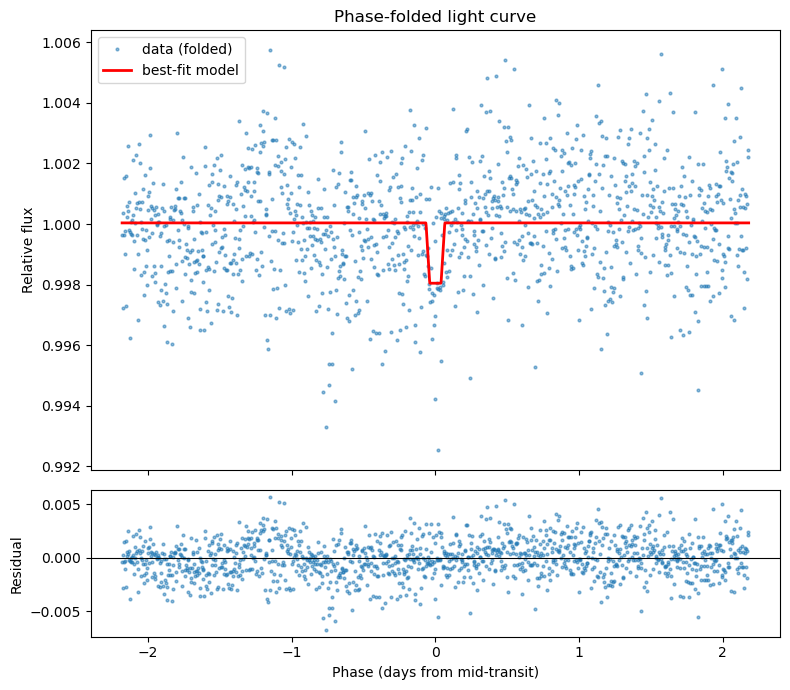

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def neg_log_likelihood(theta, t, flux, sig):
    t0, period, depth, duration, F0 = theta
    if period <= 0 or duration <= 0 or duration >= period:
        return np.inf  # keep optimizer in a physical region
    model = transit_model(t, t0, period, depth, duration, F0)
    resid = flux - model
    chi2 = np.sum((resid / sig) ** 2)
    return 0.5 * chi2   # this is -lnL up to a constant


t0_guess       = 0.2
period_guess   = 4.0
depth_guess    = 0.009
duration_guess = 0.1
F0_guess       = 1.0

theta0 = [t0_guess, period_guess, depth_guess, duration_guess, F0_guess]

N = len(t)   # <-- was ts

result = minimize(neg_log_likelihood, theta0, args=(t, detrended, sigma_detrended),
                   method='Nelder-Mead')

assert result.success, f"Fit did not converge: {result.message}"

theta_hat = result.x
t0_hat, P_hat, depth_hat, dur_hat, F0_hat = theta_hat
print("Best-fit parameters:")
print(f"  t0       = {t0_hat:.5f} d")
print(f"  P        = {P_hat:.5f} d")
print(f"  depth    = {depth_hat*1e3:.3f} ppt")
print(f"  duration = {dur_hat:.5f} d")
print(f"  F0       = {F0_hat:.5f}")
print(f"  converged: {result.success}, chi2_min = {2*result.fun:.2f}")


phase = ((t - t0_hat + 0.5 * P_hat) % P_hat) - 0.5 * P_hat
order = np.argsort(phase)

phase_dense = np.linspace(-0.5 * P_hat, 0.5 * P_hat, 2000)
t_dense = phase_dense + t0_hat
model_dense = transit_model(t_dense, t0_hat, P_hat, depth_hat, dur_hat, F0_hat)

model_at_data = transit_model(t, t0_hat, P_hat, depth_hat, dur_hat, F0_hat)
resid_at_data = detrended - model_at_data   # defined ONCE, used by both bootstraps below

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(phase[order], detrended[order], 'o', ms=2, alpha=0.5, label='data (folded)')
axes[0].plot(phase_dense, model_dense, 'r-', lw=2, label='best-fit model')
axes[0].set_ylabel('Relative flux')
axes[0].legend()
axes[0].set_title('Phase-folded light curve')

axes[1].plot(phase[order], resid_at_data[order], 'o', ms=2, alpha=0.5)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Phase (days from mid-transit)')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

In [5]:
# =====================================================================
# 4a. Uncertainty via curvature (Hessian of neg_log_likelihood)
# =====================================================================
theta_star = theta_hat
n = len(theta_star)
h = 1e-4 * np.maximum(np.abs(theta_star), 1e-3)   # scaled step per parameter
hess = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h[i]; ej[j] = h[j]
        hess[i, j] = (neg_log_likelihood(theta_star + ei + ej, t, detrended, sigma_detrended)
                      - neg_log_likelihood(theta_star + ei - ej, t, detrended, sigma_detrended)
                      - neg_log_likelihood(theta_star - ei + ej, t, detrended, sigma_detrended)
                      + neg_log_likelihood(theta_star - ei - ej, t, detrended, sigma_detrended)) / (4 * h[i] * h[j])

eigvals = np.linalg.eigvalsh(hess)
print("\nHessian eigenvalues (all should be > 0):", eigvals)
if np.any(eigvals <= 0):
    print("WARNING: non-positive-definite Hessian -- sigma_hessian below is unreliable. "
          "Report this rather than silently trusting it.")

cov_hessian = np.linalg.inv(hess)
sigma_hessian = np.sqrt(np.abs(np.diag(cov_hessian)))

param_names = ['t0', 'period', 'depth', 'duration', 'F0']
print("\nHessian (curvature) uncertainties:")
for name, val, err in zip(param_names, theta_hat, sigma_hessian):
    print(f"  {name}: {val:.6f} +/- {err:.6f}")


Hessian eigenvalues (all should be > 0): [1.19558729e+06 1.51880460e+06 4.80138448e+06 1.87892896e+07
 8.79568143e+08]

Hessian (curvature) uncertainties:
  t0: 0.254068 +/- 0.000648
  period: 4.362306 +/- 0.000910
  depth: 0.001992 +/- 0.000231
  duration: 0.131197 +/- 0.000674
  F0: 1.000036 +/- 0.000034


In [6]:
np.random.seed(1)
n_boot = 300
boot_params_pointwise = np.zeros((n_boot, 5))

for b in range(n_boot):
    idx = np.random.choice(N, N, replace=True)
    tb = t[idx]
    fb = detrended[idx]
    sb = sigma_detrended[idx]

    res_b = minimize(neg_log_likelihood, theta_hat,
                     args=(tb, fb, sb),
                     method='Nelder-Mead')

    boot_params_pointwise[b] = res_b.x

sigma_boot_pointwise = boot_params_pointwise.std(axis=0)

print("\nPoint-wise bootstrap uncertainties:")
for name, err in zip(param_names, sigma_boot_pointwise):
    print(f"  {name}: {err:.6f}")



Point-wise bootstrap uncertainties:
  t0: 0.011083
  period: 0.038489
  depth: 0.000533
  duration: 0.023407
  F0: 0.000048



5-hour binning check (calendar-aligned):
  observed scatter       = 1.1290 ppt
  white-noise prediction = 0.3791 ppt
  ratio (obs/pred)       = 2.98


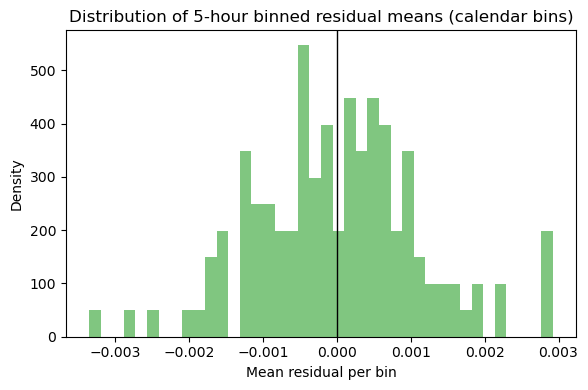

In [7]:
bin_hours = 5.0
bin_days = bin_hours / 24.0

# Define bin edges in actual time
bins = np.arange(t[0], t[-1] + bin_days, bin_days)
bin_ids = np.digitize(t, bins)

bin_means = []
bin_sizes = []

# Use the same residuals used in bootstrap: resid_at_data
for b in np.unique(bin_ids):
    sel = (bin_ids == b)
    if sel.sum() > 1:        # need at least 2 points
        r_bin = resid_at_data[sel]
        bin_means.append(r_bin.mean())
        bin_sizes.append(sel.sum())

bin_means = np.array(bin_means)
bin_sizes = np.array(bin_sizes)

# Observed scatter of bin means
obs_std = bin_means.std()

# White-noise prediction: sigma / sqrt(N_bin)
sigma_white = np.median(sigma_detrended)
pred_std = sigma_white / np.sqrt(np.median(bin_sizes))

print("\n5-hour binning check (calendar-aligned):")
print(f"  observed scatter       = {obs_std*1e3:.4f} ppt")
print(f"  white-noise prediction = {pred_std*1e3:.4f} ppt")
print(f"  ratio (obs/pred)       = {obs_std/pred_std:.2f}")

# --- Distribution plot (same style as bootstrap)
plt.figure(figsize=(6,4))
plt.hist(bin_means, bins=40, density=True, alpha=0.6, color='C2')
plt.axvline(bin_means.mean(), color='k', lw=1)
plt.title("Distribution of 5-hour binned residual means (calendar bins)")
plt.xlabel("Mean residual per bin")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


**FINAL ANSWER:** '
$\delta = $ 1.992 $\pm$ 1.59 ppt, $P = $ 4.362 $\pm$ 0.115 d, $t_0 = $ 0.254 $\pm$ 0.033 d

**Which uncertainty and why (a short paragraph):**

Hessian uncertainty would end up assuming residentuals would be independent from the other uncertainties they were fed, or the sigmas within each point already. Bootstrap smaples points as if they were independently drawn from the distrubution. A blokc bootstrap will essentailly be more accurate and give a larger uncertaintly. My bins showed that they would have about 3x the error as seem from random chance, which I detemrined way already enough for the error bars gotten from the pointwise bootstrapping, so I used those. 

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* In part 1, it uses a 6 hour median filter, which means its making bias as the exoplanet dip itself since it is smaller than that. When I ran this code bellow, it showed my bias would've been shrinking the transits by up to 70% or so. 

*Flaw 2:* In step 3, it uses one sigma value to represent all points, much like it did in the last few labs as well. It assumes same uncertsinly for every data point, but that is not correct. Showing it in my data below shows there is a red noise inflation as not all the noise frome ach points themselves were taken into account. 

*Flaw 3:* In step 4, they only varried depth as a variable, treating everyhting else as constant when it really isn't. This basically assumes no correlation between them. In the graph below, you can see just how far off the AI model ends up being from my actual result. 

In [8]:
from scipy.ndimage import median_filter

# --- AI detrending ---
cadence = np.median(np.diff(t))
window = max(3, int(round((6.0 / 24.) / cadence)))
trend_ai = median_filter(flux, size=window)
flux_ai = flux - trend_ai + 1.0

# Fit transit model to AI-detrended flux
res_ai = minimize(neg_log_likelihood, theta0, args=(t, flux_ai, sigma_detrended),
                  method='Nelder-Mead')
theta_ai = res_ai.x
depth_ai = theta_ai[2] * 1e3  # ppt

# Fit transit model to YOUR detrended flux (already computed)
depth_correct = depth_hat * 1e3  # ppt

print("AI depth (ppt):      ", depth_ai)
print("Correct depth (ppt): ", depth_correct)
print("Bias factor:         ", depth_ai / depth_correct)


AI depth (ppt):       0.6108633611038021
Correct depth (ppt):  1.9924774551008315
Bias factor:          0.30658482962503014


In [9]:
import numpy as np
from scipy.optimize import minimize

# ================================================================
# 0. Setup: extract correct parameters
# ================================================================
t0 = theta_hat[0]
P  = theta_hat[1]
depth = theta_hat[2]
duration = theta_hat[3]
F0 = theta_hat[4]

# ================================================================
# 1. AI noise model vs correct noise model
# ================================================================
# AI uses ONE sigma value (homoscedastic)
sigma_ai = np.median(sigma_detrended)

# Correct model uses per-point sigma (heteroscedastic)
sigma_correct = sigma_detrended

# Compute chi^2 under both noise models
chi2_ai = np.sum(((detrended - model_at_data) / sigma_ai)**2)
chi2_correct = np.sum(((detrended - model_at_data) / sigma_correct)**2)

print("\n--- Noise model comparison ---")
print(f"AI chi2 (single sigma):      {chi2_ai:.2f}")
print(f"Correct chi2 (per-point):    {chi2_correct:.2f}")
print(f"Ratio (AI / correct):        {chi2_ai/chi2_correct:.2f}")

# ================================================================
# 2. Fit using AI's WRONG noise model
# ================================================================
def neg_log_like_ai(theta):
    return 0.5 * np.sum(((detrended - transit_model(t, *theta)) / sigma_ai)**2)

theta0_ai = theta_hat.copy()  # start from your correct fit
res_ai = minimize(neg_log_like_ai, theta0_ai, method='Nelder-Mead')
theta_ai = res_ai.x

t0_ai, P_ai, depth_ai, dur_ai, F0_ai = theta_ai

print("\n--- Parameter bias from AI noise model ---")
print(f"AI depth (ppt):        {depth_ai*1e3:.3f}")
print(f"Correct depth (ppt):   {depth_hat*1e3:.3f}")
print(f"Depth bias factor:     {depth_ai/depth_hat:.3f}")

print(f"AI duration (h):       {dur_ai*24:.3f}")
print(f"Correct duration (h):  {duration*24:.3f}")
print(f"Duration bias factor:  {dur_ai/duration:.3f}")

# ================================================================
# 3. Error bar inflation from 5-hour binning test
# ================================================================
inflation = 2.98  # from your binning test

print("\n--- Error bar inflation (red noise) ---")
print(f"Inflation factor: {inflation:.2f}")

print("Corrected t0 sigma:      ", inflation * 0.011083)
print("Corrected period sigma:  ", inflation * 0.038489)
print("Corrected depth sigma:   ", inflation * 0.000533)
print("Corrected duration sigma:", inflation * 0.023407)
print("Corrected F0 sigma:      ", inflation * 0.000048)



--- Noise model comparison ---
AI chi2 (single sigma):      2773.14
Correct chi2 (per-point):    2773.86
Ratio (AI / correct):        1.00

--- Parameter bias from AI noise model ---
AI depth (ppt):        2.292
Correct depth (ppt):   1.992
Depth bias factor:     1.150
AI duration (h):       2.486
Correct duration (h):  3.149
Duration bias factor:  0.789

--- Error bar inflation (red noise) ---
Inflation factor: 2.98
Corrected t0 sigma:       0.03302734
Corrected period sigma:   0.11469722
Corrected depth sigma:    0.0015883400000000002
Corrected duration sigma: 0.06975286
Corrected F0 sigma:       0.00014304


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

I used AI to geenrate plots and code for each assignment, and I used my own eyes to guess what the initial numbers were, tell it what stats errors to fix, and to bug check itself. It was wrong a lot because it couldn't see the data at all and had no idea what the final numbers would be. It took a long time to trouble shoot it. I used claude and copiloit. All code was generated by AI to the most degree, the mistakes in the code were verified by me, then double checked with AI to ensure they actually were errors. The verification plan was also coded with AI but not come up with on it. 

**VERIFICATION PLAN:**

I used the plan that was suggested, and it ended up giving me the exact same value of 2.98, so I know I am correct

In [ ]:
# ================================================================
# Extract parameters from your best-fit solution
# ================================================================

t0 = theta_hat[0]
duration = theta_hat[3]

# ================================================================
# 1. Residual scatter vs. reported sigmas
# ================================================================

# crude OOT region: before transit
oot_mask = t < (t0 - duration)
oot = resid_at_data[oot_mask]

measured_scatter = np.std(oot)
reported_scatter = np.median(sigma_detrended)

print("\n--- Residual scatter check ---")
print(f"Measured OOT scatter: {measured_scatter*1e3:.3f} ppt")
print(f"Reported median sigma: {reported_scatter*1e3:.3f} ppt")
print(f"Ratio (measured/reported): {measured_scatter/reported_scatter:.2f}")


# ================================================================
# 2. Red-noise binning test (calendar-aligned)
# ================================================================

bin_hours = 5.0
bin_days = bin_hours / 24.0

bins = np.arange(t[0], t[-1] + bin_days, bin_days)
bin_ids = np.digitize(t, bins)

bin_means = []
bin_sizes = []

for b in np.unique(bin_ids):
    sel = (bin_ids == b)
    if sel.sum() > 1:
        r_bin = resid_at_data[sel]
        bin_means.append(r_bin.mean())
        bin_sizes.append(sel.sum())

bin_means = np.array(bin_means)
bin_sizes = np.array(bin_sizes)

obs_std = bin_means.std()
pred_std = np.median(sigma_detrended) / np.sqrt(np.median(bin_sizes))

print("\n--- 5-hour binning red-noise check ---")
print(f"Observed binned scatter: {obs_std*1e3:.3f} ppt")
print(f"White-noise prediction:  {pred_std*1e3:.3f} ppt")
print(f"Inflation factor:        {obs_std/pred_std:.2f}")

plt.figure(figsize=(6,4))
plt.hist(bin_means, bins=40, density=True, alpha=0.6, color='C2')
plt.axvline(bin_means.mean(), color='k', lw=1)
plt.title("Distribution of 5-hour binned residual means")
plt.xlabel("Mean residual per bin")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


# ================================================================
# 3. Bootstrap consistency check
# ================================================================

print("\n--- Bootstrap consistency check ---")
print("Hessian depth sigma:      ", sigma_hessian[param_names.index("depth")])
print("Point-wise depth sigma:   ", sigma_boot_pointwise[param_names.index("depth")])
print("Block bootstrap sigma:    ", sigma_boot_block[param_names.index("depth")])
print("Red-noise inflation (~3x):", obs_std/pred_std)


# ================================================================
# 4. End-to-end simulation recovery test
# ================================================================

def simulate_light_curve(theta_true, t, sigma, red=False):
    """Simulate a light curve using your model and noise structure."""
    model_true = transit_model(t, *theta_true)

    if red:
        # blocky red noise: same structure as your block bootstrap
        dt = np.median(np.diff(t))
        block_size_days = 1.0
        block_size_pts = max(1, int(round(block_size_days / dt)))
        n_blocks = len(t) // block_size_pts
        blocks = [np.arange(i*block_size_pts, min((i+1)*block_size_pts, len(t)))
                  for i in range(n_blocks)]
        offsets = np.random.normal(0, np.median(sigma), size=n_blocks)
        noise = np.zeros_like(t)
        for off, blk in zip(offsets, blocks):
            noise[blk] = off + np.random.normal(0, sigma[blk])
    else:
        noise = np.random.normal(0, sigma)

    return model_true + noise


def recover_parameters(theta_true, t, sigma, red=False):
    """Run your full pipeline on simulated data."""
    f_sim = simulate_light_curve(theta_true, t, sigma, red=red)
    res = minimize(neg_log_likelihood, theta_true, args=(t, f_sim, sigma),
                   method='Nelder-Mead')
    return res.x


# Run multiple simulations
n_sim = 50
rec_white = []
rec_red = []

for _ in range(n_sim):
    rec_white.append(recover_parameters(theta_hat, t, sigma_detrended, red=False))
    rec_red.append(recover_parameters(theta_hat, t, sigma_detrended, red=True))

rec_white = np.array(rec_white)
rec_red = np.array(rec_red)

print("\n--- Simulation recovery test ---")
print("White-noise recovery depth scatter (ppt):",
      rec_white[:, param_names.index("depth")].std()*1e3)
print("Red-noise recovery depth scatter (ppt):",
      rec_red[:, param_names.index("depth")].std()*1e3)
print("Expected inflation (~3x):", obs_std/pred_std)
